<a href="https://colab.research.google.com/github/m00n07/mineria_de_datos/blob/main/3P/Proyecto/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Equipo:
Edgar
Natasha

In [ ]:
!pip install resampy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 10.5 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iniciando extracción de MFCC con limpieza de silencios...
Cargando 11 archivos de: /content/drive/MyDrive/ProyectoAudio/Librosa/encenderluz
Directorio encontrado: /content/drive/MyDrive/ProyectoAudio/Librosa/encenderluz (11 archivos)


/tmp/ipykernel_4637/1480577819.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_4637/1480577819.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Cargando 13 archivos de: /content/drive/MyDrive/ProyectoAudio/Librosa/apagarluz
Directorio encontrado: /content/drive/MyDrive/ProyectoAudio/Librosa/apagarluz (13 archivos)


/tmp/ipykernel_4637/1480577819.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_4637/1480577819.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



✅ Procesamiento terminado. Muestras totales: 24

Entrenando el modelo...
Epoch 1/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 285ms/step - accuracy: 0.2632 - loss: 0.7524 - val_accuracy: 0.4000 - val_loss: 0.7363
Epoch 2/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7895 - loss: 0.5340 - val_accuracy: 0.4000 - val_loss: 0.6955
Epoch 3/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6316 - loss: 0.5042 - val_accuracy: 0.6000 - val_loss: 0.6644
Epoch 4/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7895 - loss: 0.4639 - val_accuracy: 0.6000 - val_loss: 0.6646
Epoch 5/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8421 - loss: 0.3979 - val_accuracy: 0.6000 - val_loss: 0.6892
Epoch 6/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8421 - loss: 0.4079 - val_accuracy: 0.6000 - val_loss: 0.7156
Epoch 7/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9474 - loss: 0.3017 - val_accuracy: 0.6000 - val_loss: 0.7754
Epoch 8/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step -

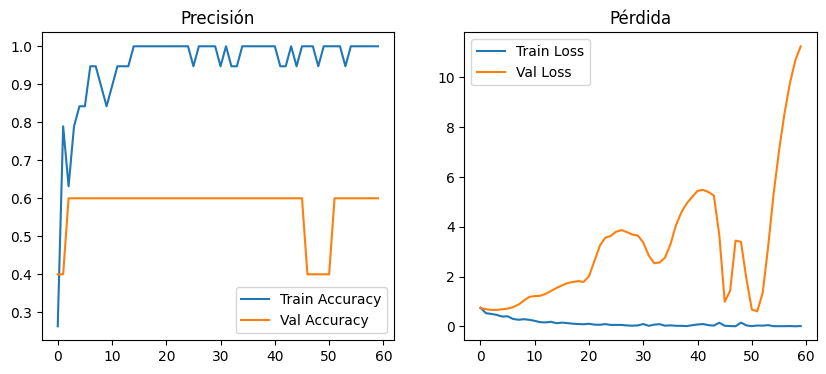


Analizando audio de prueba: /content/drive/MyDrive/ProyectoAudio/Librosa/apagarluz/apagar_.wav

Analizando: /content/drive/MyDrive/ProyectoAudio/Librosa/apagarluz/apagar_.wav
>>> RESULTADO: [ LUZ ENCENDIDA ] (Confianza: 1.0000)

Analizando audio de prueba: /content/drive/MyDrive/ProyectoAudio/Librosa/encenderluz/encender_.wav

Analizando: /content/drive/MyDrive/ProyectoAudio/Librosa/encenderluz/encender_.wav
>>> RESULTADO: [ LUZ ENCENDIDA ] (Confianza: 1.0000)


"\npredecir_luz('/content/drive/MyDrive/ProyectoAudio/apagar/apagar2.wav')\npredecir_luz('/content/drive/MyDrive/ProyectoAudio/encender/encender2.wav')\n"

In [ ]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from google.colab import drive

# --- FASE 1: MONTAJE Y CONFIGURACIÓN ---
drive.mount('/content/drive')

# Rutas exactas confirmadas por el usuario
"""
PATH_ENCENDER = '/content/drive/MyDrive/ProyectoAudio/encender'
PATH_APAGAR = '/content/drive/MyDrive/ProyectoAudio/apagar'
"""

PATH_ENCENDER = '/content/drive/MyDrive/ProyectoAudio/Librosa/apagarluz'
PATH_APAGAR = '/content/drive/MyDrive/ProyectoAudio/Librosa/encenderluz'



# --- FASE 2: PROCESAMIENTO DE AUDIO (MFCC) ---
def extract_features(file_path, max_pad_len=40):
    try:
        # Carga del audio (requiere resampy instalado)
        audio, sr = librosa.load(file_path, res_type='kaiser_fast')

        # CAMBIO 1: Eliminación de silencios al inicio y al final
        audio, _ = librosa.effects.trim(audio)

        # Extracción de características
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        # Ajuste de tamaño (Padding/Truncado) para obtener 40x40
        if (mfccs.shape[1] < max_pad_len):
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]
        return mfccs
    except Exception as e:
        print(f"Error procesando {file_path}: {e}")
        return None

X, y = [], []

# Diccionario para automatizar la carga
carpetas = {0: PATH_APAGAR, 1: PATH_ENCENDER}

# print("Iniciando extracción de MFCC...")
# CAMBIO
print("Iniciando extracción de MFCC con limpieza de silencios...")
# FIN CAMBIO
for etiqueta, ruta in carpetas.items():
    if os.path.exists(ruta):
        # Buscamos archivos .wav (ignorando mayúsculas/minúsculas)
        archivos = [f for f in os.listdir(ruta) if f.lower().endswith('.wav')]
        # CAMBIO
        print(f"Cargando {len(archivos)} archivos de: {ruta}")
        # FIN CAMBIO
        print(f"Directorio encontrado: {ruta} ({len(archivos)} archivos)")

        for p in archivos:
            data = extract_features(os.path.join(ruta, p))
            if data is not None:
                X.append(data)
                y.append(etiqueta)
    else:
        print(f"❌ ERROR: No se encontró la ruta: {ruta}")

# Conversión a NumPy y Normalización
X = np.array(X)
y = np.array(y)

if len(X) > 0:

    # CAMBIO
    # Guardamos los valores globales para la normalización posterior
    X_min = np.min(X)
    X_max = np.max(X)
    X = (X - X_min) / (X_max - X_min)
    # FIN CAMBIO

    # Normalización entre 0 y 1
    # X = (X - np.min(X)) / (np.max(X) - np.min(X))

    # División de datos (80% entrenamiento, 20% validación)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\n✅ Procesamiento terminado. Muestras totales: {len(X)}")
else:
    print("\n❌ Error Crítico: No se cargaron datos. Verifica tus carpetas en Drive.")

# --- FASE 3: MODELO Y ENTRENAMIENTO ---
if len(X) > 0:
    """model = models.Sequential([
        layers.Input(shape=(40, 40)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid') # Salida binaria: 0 (Apagar) o 1 (Encender)
    ])"""
    # CAMBIO
    model = models.Sequential([
        layers.Input(shape=(40, 40)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'), # Aumentamos neuronas
        layers.BatchNormalization(),          # Ayuda a estabilizar el aprendizaje
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),                  # Bajamos un poco el dropout
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    # FIN CAMBIO

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    print("\nEntrenando el modelo...")
    # history = model.fit(X_train, y_train, epochs=50, batch_size=16,
                        # validation_data=(X_val, y_val), verbose=1)
    # CAMBIO
    history = model.fit(X_train, y_train, epochs=60, batch_size=16,
                        validation_data=(X_val, y_val), verbose=1)
    # FIN CAMBIO

    # Gráficas de Rendimiento
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend(); plt.title('Precisión')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend(); plt.title('Pérdida')
    plt.show()

# --- FASE 4: SIMULACIÓN Y PRUEBA (VOZ DEL PROFESOR) ---
def predecir_luz(ruta_audio):
    print(f"\nAnalizando audio de prueba: {ruta_audio}")
    nuevo_mfcc = extract_features(ruta_audio)
    if nuevo_mfcc is not None:
        # Normalización (usando los mismos parámetros)
        # nuevo_mfcc = (nuevo_mfcc - np.min(nuevo_mfcc)) / (np.max(nuevo_mfcc) - np.min(nuevo_mfcc))
        # CAMBIO 3: Normalización usando los parámetros globales del entrenamiento
        nuevo_mfcc = (nuevo_mfcc - X_min) / (X_max - X_min)
        # FIN CAMBIO
        nuevo_mfcc = nuevo_mfcc.reshape(1, 40, 40)

        prediccion = model.predict(nuevo_mfcc, verbose=0)
        # CAMBIO
        confianza = prediccion[0][0]

        print(f"\nAnalizando: {ruta_audio}")
        # FIN CAMBIO

        """
        if prediccion[0][0] >= 0.5:
            print(f">>> RESULTADO: [ LUZ ENCENDIDA ] (Confianza: {prediccion[0][0]:.4f})")
        else:
            print(f">>> RESULTADO: [ LUZ APAGADA ] (Confianza: {1-prediccion[0][0]:.4f})")"""
        # CAMBIO
        if confianza >= 0.5:
            print(f">>> RESULTADO: [ LUZ ENCENDIDA ] (Confianza: {confianza:.4f})")
        else:
            print(f">>> RESULTADO: [ LUZ APAGADA ] (Confianza: {1 - confianza:.4f})")
        # FIN CAMBIO
    else:
        print("No se pudo procesar el audio de prueba.")


# --- EJEMPLOS DE PRUEBA ---

predecir_luz('/content/drive/MyDrive/ProyectoAudio/Librosa/apagarluz/apagar_.wav')
predecir_luz('/content/drive/MyDrive/ProyectoAudio/Librosa/encenderluz/encender_.wav')
"""
predecir_luz('/content/drive/MyDrive/ProyectoAudio/apagar/apagar2.wav')
predecir_luz('/content/drive/MyDrive/ProyectoAudio/encender/encender2.wav')
"""


# Para probar con la voz del profesor, coloca el archivo en Drive y cambia la ruta:
# 1. Definir la ruta exacta
# ruta_profesor = '/content/drive/MyDrive/ProyectoAudio/prueba_profe.wav'

# 2. Llamar a la función de predicción
# predecir_luz(ruta_profesor)